# Selectividad institucional e ingresos posteriores de graduados de Computer Science
**Joel Vega Díaz · INSM 7020 – Asignación #2 · Universidad Interamericana de Puerto Rico, Recinto de Ponce**

Informe reproducible en Python. Datos: U.S. Department of Education, College Scorecard, archivos `FieldOfStudyData2122_2223_PP.csv` y `MERGED2022_23_PP.csv` (publicación de junio de 2026; licencia abierta registrada en el catálogo de data.gov). El script completo `Joel_Vega_INSM7020_Asignacion2_Analisis.py` genera todas las tablas y figuras que se leen en este informe.

**Pregunta:** ¿qué relación existe entre la selectividad institucional (tasa de admisión) y el ingreso mediano de los graduados de bachillerato en Computer Science cuatro años después de completar el programa?

**Diseño:** 742 OPEID6 con programa de CS → 316 con ingreso y tasa de admisión válidos (marco analítico) → muestra aleatoria estratificada proporcional de **n = 174** (95 % de confianza, ±5 %, corrección finita; semilla 7020).

Instituciones en la muestra: 174


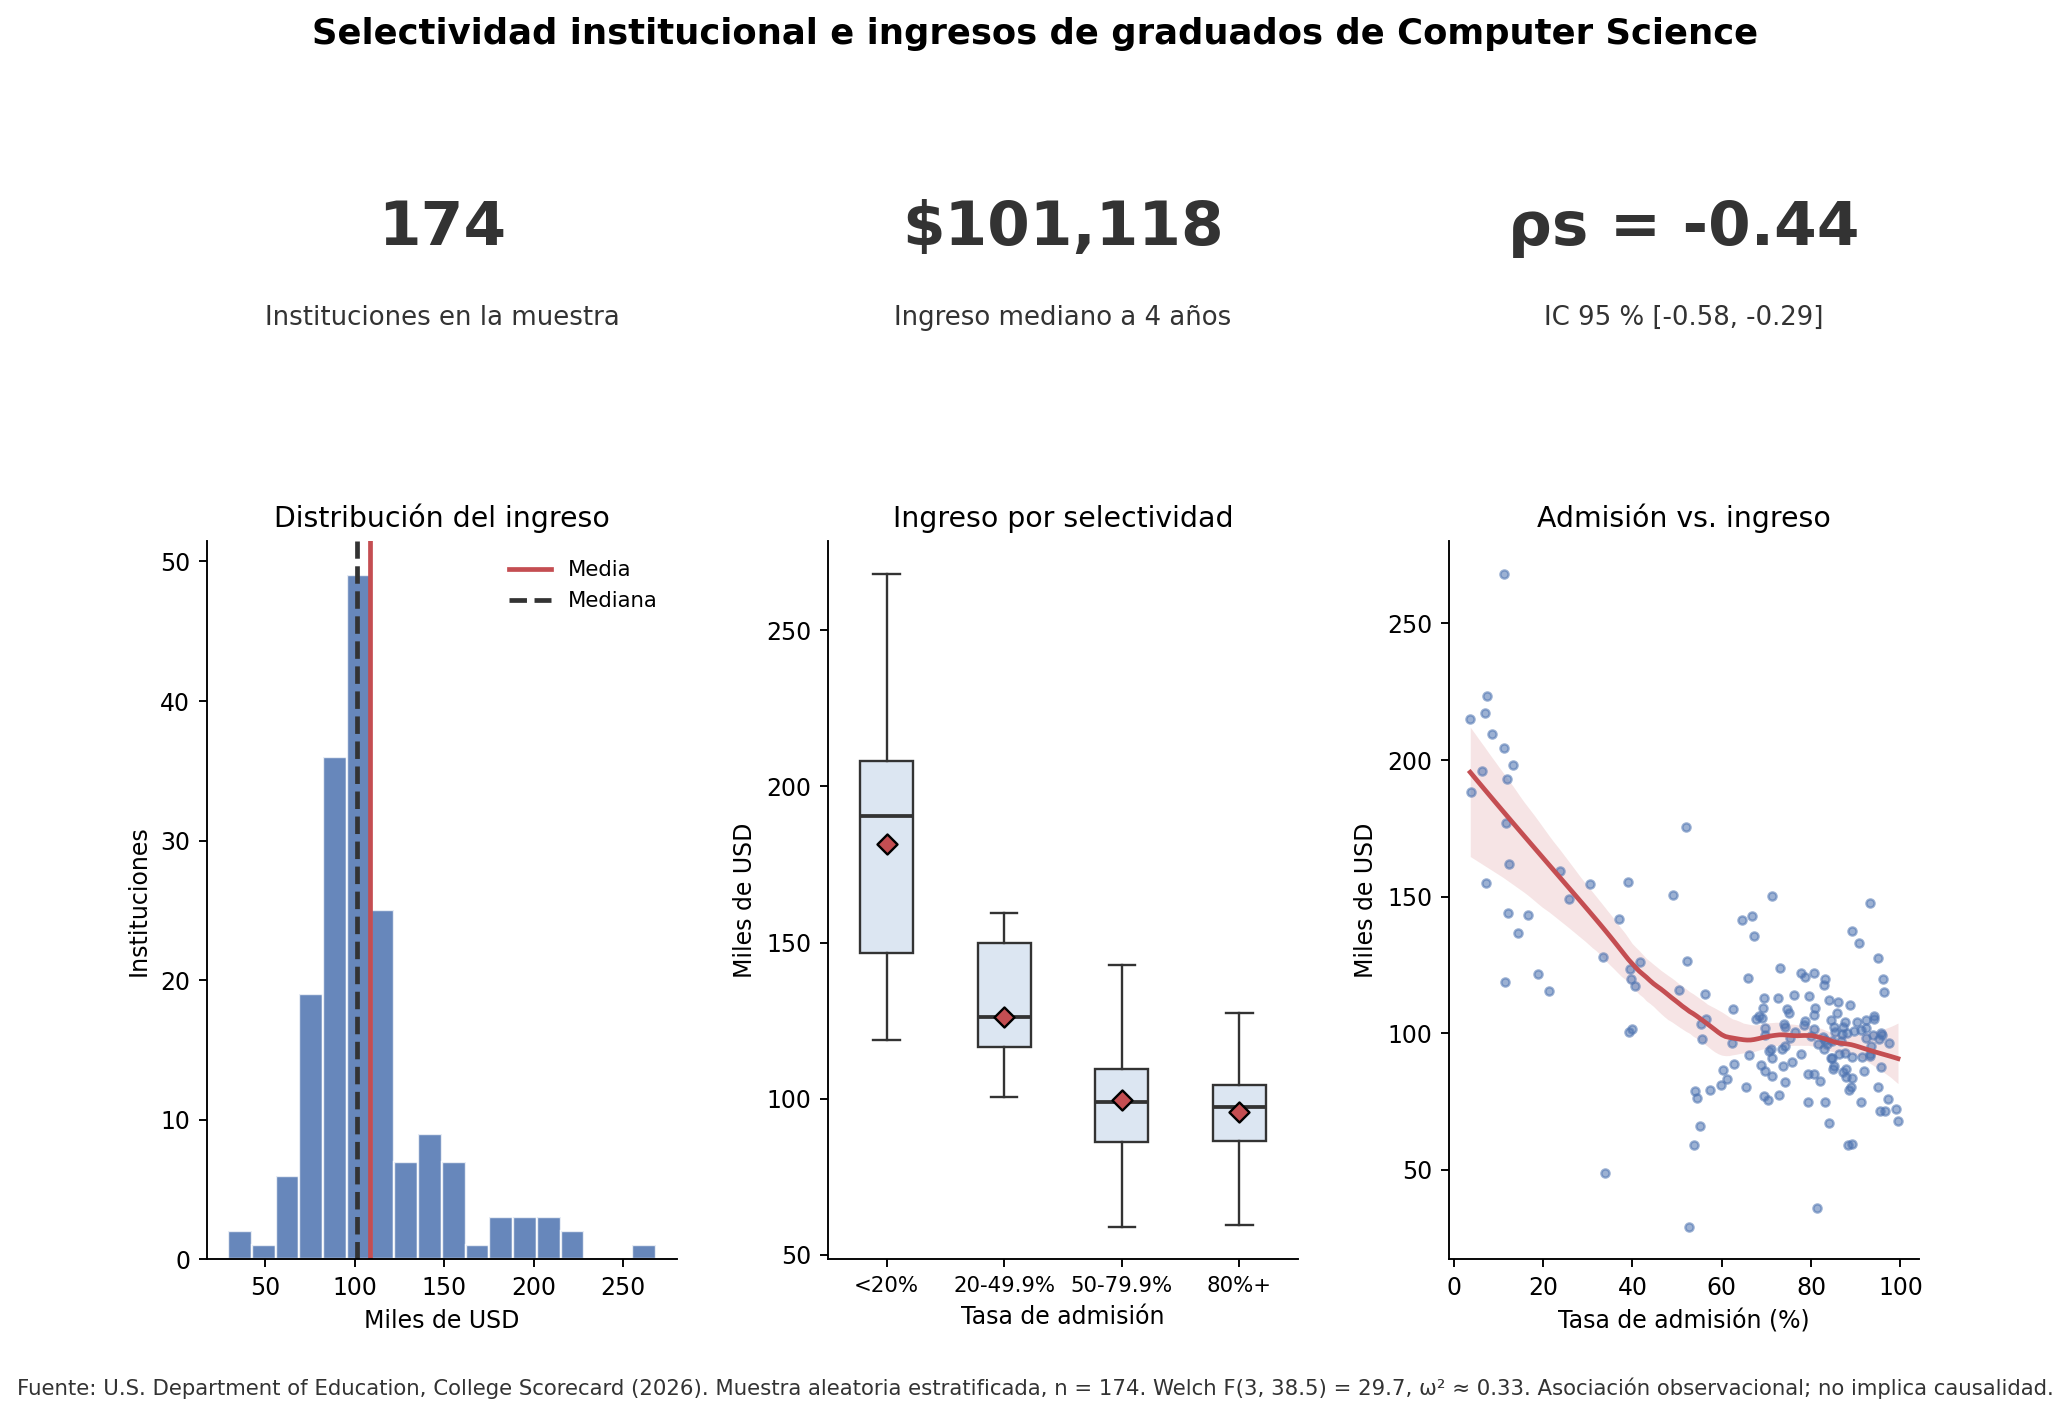

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Image, Markdown
S = Path('salidas_asignacion2')
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
df = pd.read_csv(S / 'muestra_analitica.csv')
print(f'Instituciones en la muestra: {len(df)}')
display(Image(filename=str(S / 'tablero_informe.png'), width=900))

## 1. Evaluación del descarte
Las instituciones excluidas por no tener ingreso publicado tienen una selectividad casi idéntica a las incluidas, pero son mucho más pequeñas y más a menudo privadas. El marco representa mejor a los programas de tamaño medio y grande.

In [2]:
display(pd.read_csv(S / 'sesgo_descarte.csv').replace({'en_marco': {False: 'Excluidas', True: 'Marco analítico'}}))

,en_marco,n,admision_mediana,matricula_ug_mediana,graduados_cs_mediana,pct_privadas
0,Excluidas,426,0.753,"1,732.000",8.000,75.587
1,Marco analítico,316,0.755,"6,036.000",50.000,46.835


## 2. Estadística descriptiva

In [3]:
display(pd.read_csv(S / 'estadisticos_descriptivos.csv'))
display(pd.read_csv(S / 'frecuencias_categoricas.csv'))

,variable,n,media,mediana,DE,min,Q1,Q3,max
0,EARN_MDN_4YR,174,"108,652.891","101,117.500","35,160.250","29,212.000","88,177.750","119,497.250","268,121.000"
1,admit_rate,174,0.683,0.759,0.259,0.037,0.563,0.874,0.995
2,UGDS,174,"10,688.552","7,082.000","13,212.530",673.000,"2,913.250","13,857.500","138,138.000"
3,sat_avg,133,"1,248.767","1,236.000",156.412,915.000,"1,121.000","1,370.000","1,554.000"


,variable,categoria,n,pct
0,Grupo de selectividad,Acceso amplio (80%+),76,43.700
1,Grupo de selectividad,Altamente selectiva (<20%),18,10.300
2,Grupo de selectividad,Moderada (50-79.9%),65,37.400
3,Grupo de selectividad,Selectiva (20-49.9%),15,8.600
4,Control institucional,"Private, nonprofit",83,47.700
5,Control institucional,Public,91,52.300
6,Region IPEDS,1,17,9.800
7,Region IPEDS,2,28,16.100
8,Region IPEDS,3,30,17.200
9,Region IPEDS,4,12,6.900


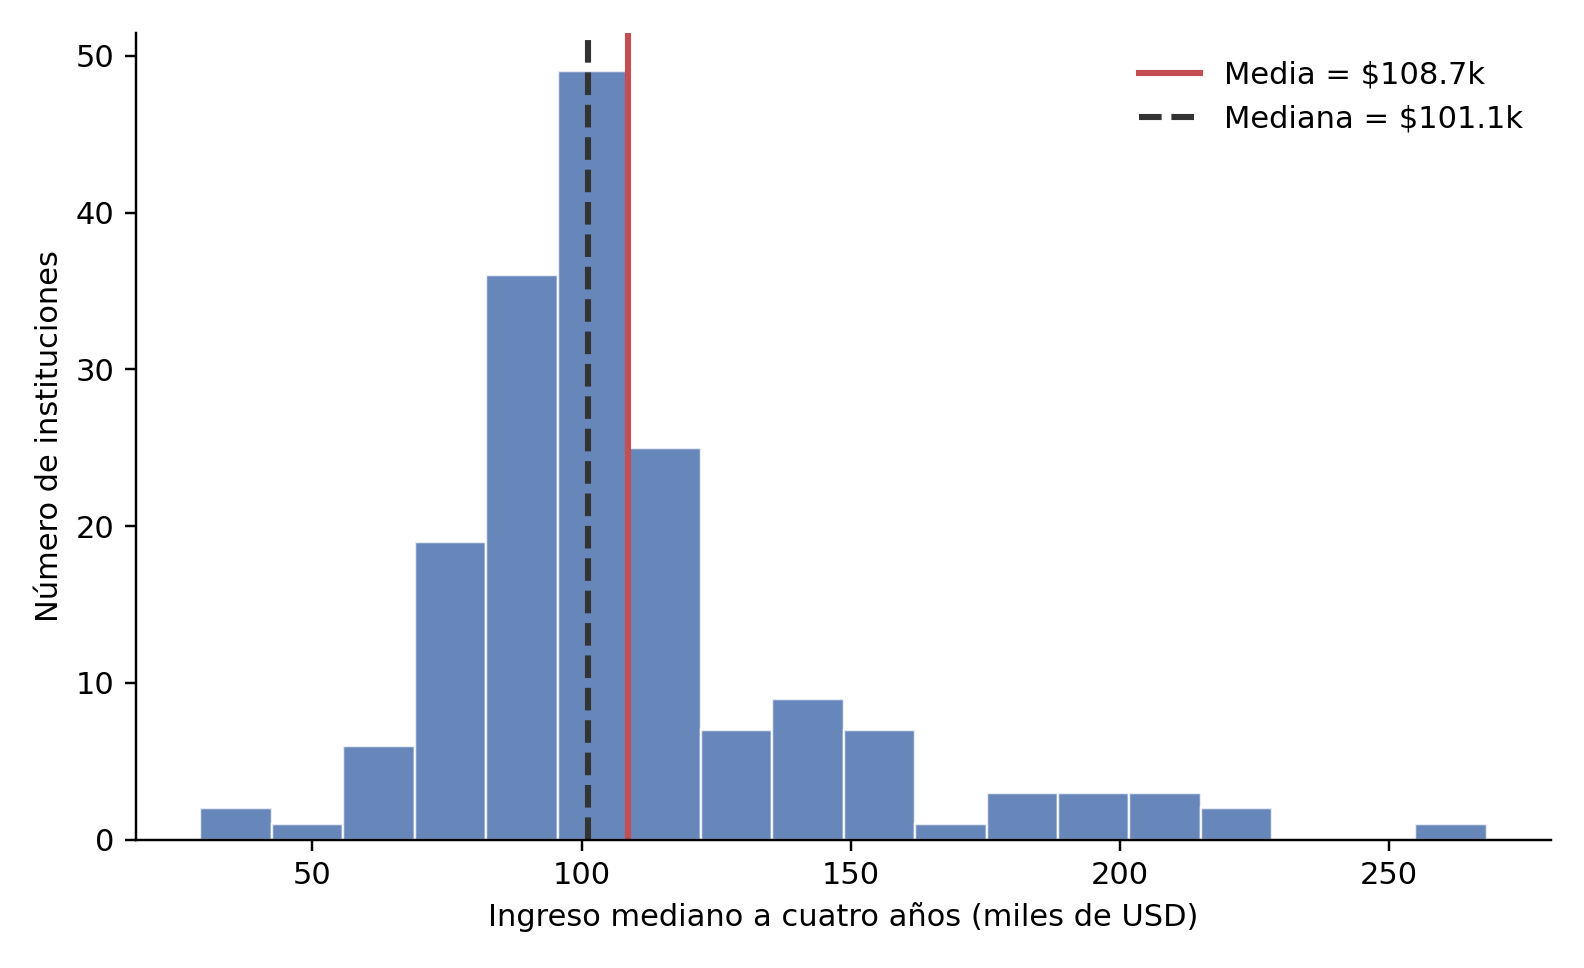

Figura 1. Distribución del ingreso mediano a cuatro años (n = 174). *Fuente:* U.S. Department of Education, College Scorecard (publicación de junio de 2026).

In [4]:
display(Image(filename=str(S / 'figura1_histograma.png'), width=720))
display(Markdown('Figura 1. Distribución del ingreso mediano a cuatro años (n = 174). *Fuente:* U.S. Department of Education, College Scorecard (publicación de junio de 2026).'))

## 3. Inferencia principal: correlación de Spearman
$H_0: \rho_s = 0$ frente a $H_1: \rho_s \neq 0$. Se usa Spearman por la asimetría positiva del ingreso (asimetría 1.56; Shapiro-Wilk p < .001).

In [5]:
res = (S / 'resumen_resultados.txt').read_text(encoding='utf-8').splitlines()
for line in res:
    if line.startswith(('Spearman', 'Sensibilidad', 'Contraste', 'Asimetria')):
        print(line)

Asimetria=1.56; curtosis (exceso)=3.65; Shapiro-Wilk W=0.872, p=4.96e-11; atipicos 1.5*RIC=14; SAT faltante=41
Spearman rho=-0.444; t(172)=-6.50; p=8.41e-10; IC95 bootstrap=[-0.582, -0.288]
Sensibilidad Pearson r=-0.671; p=3.71e-24
Contraste con el marco completo (N=316): rho=-0.452; p=2.36e-17
Sensibilidad sin Puerto Rico (n=172): rho=-0.474; p=5.11e-11


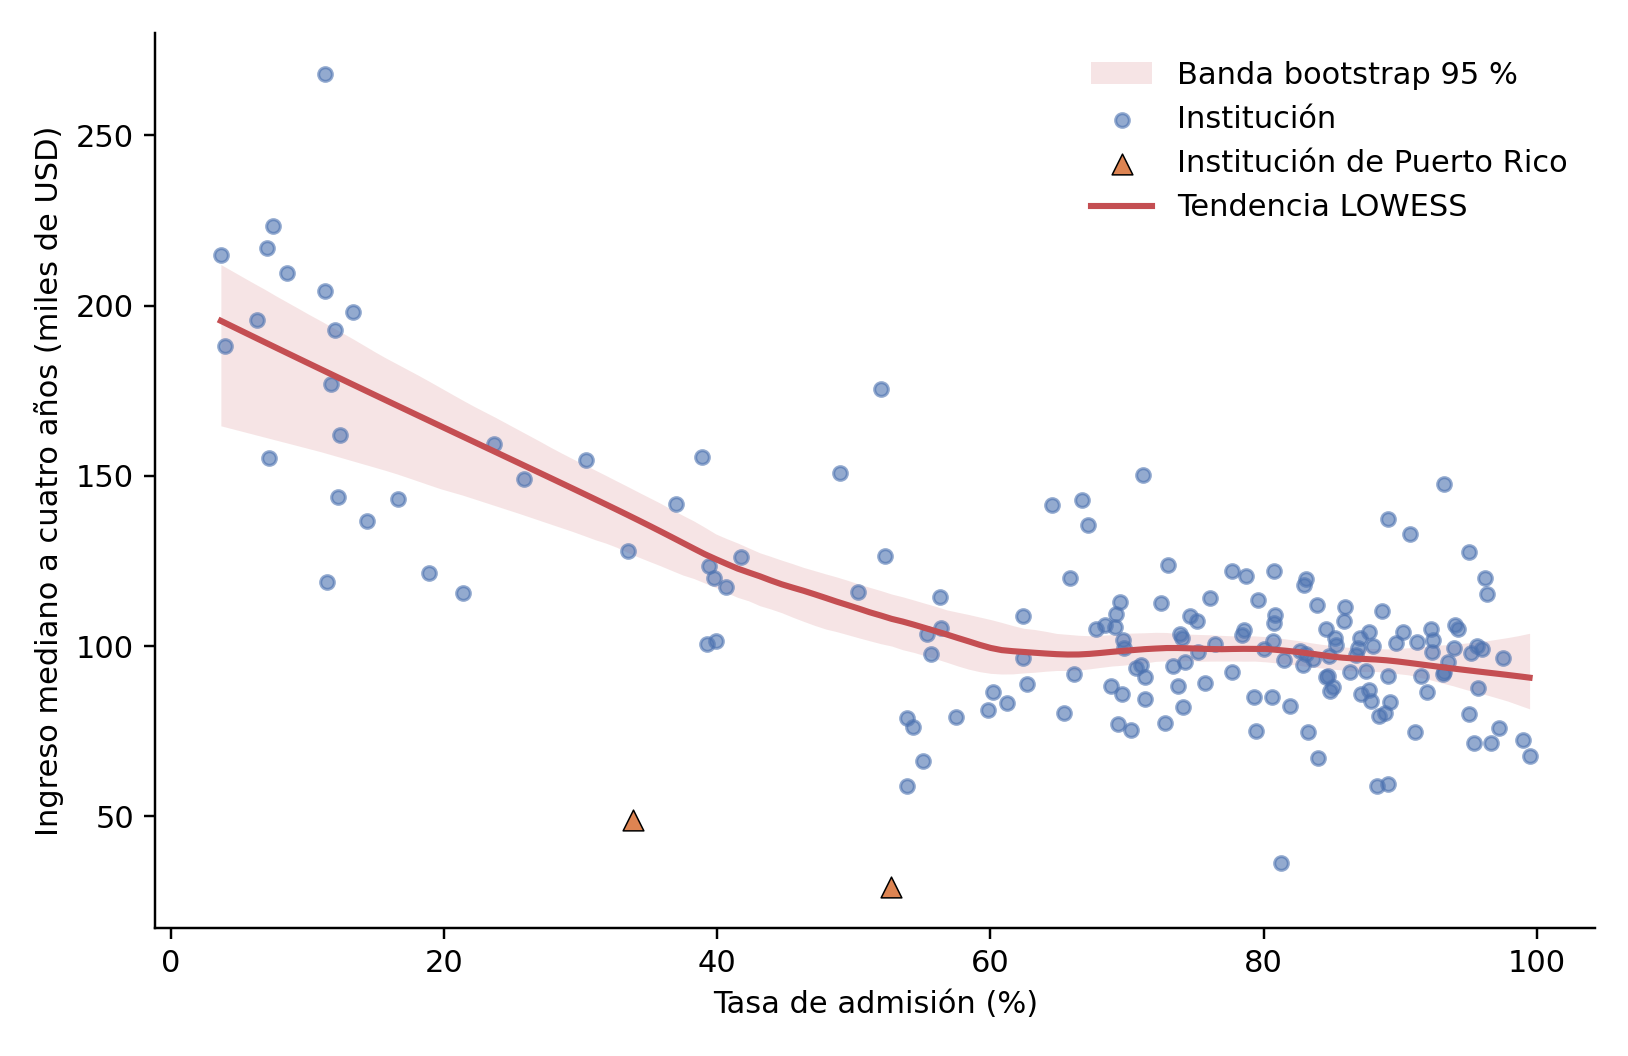

Figura 2. Tasa de admisión e ingreso con tendencia LOWESS y banda bootstrap del 95 % (n = 174). *Fuente:* U.S. Department of Education, College Scorecard (publicación de junio de 2026).

In [6]:
display(Image(filename=str(S / 'figura2_dispersion.png'), width=720))
display(Markdown('Figura 2. Tasa de admisión e ingreso con tendencia LOWESS y banda bootstrap del 95 % (n = 174). *Fuente:* U.S. Department of Education, College Scorecard (publicación de junio de 2026).'))

## 4. Comparación por grupos: ANOVA de Welch

In [7]:
for line in res:
    if line.startswith(('Levene', 'Welch')):
        print(line)
display(pd.read_csv(S / 'ingreso_por_grupo.csv'))
display(pd.read_csv(S / 'comparaciones_holm.csv'))

Levene W=7.59; p=8.52e-05
Welch F(3, 38.53)=29.70; p=4.06e-10; omega2 estimada=0.33


,selectivity_group,count,mean,median,std
0,Altamente selectiva (<20%),18,"181,722.889","190,581.000","39,922.631"
1,Selectiva (20-49.9%),15,"126,163.200","126,183.000","28,851.465"
2,Moderada (50-79.9%),65,"99,693.292","99,067.000","22,332.691"
3,Acceso amplio (80%+),76,"95,553.671","97,145.500","17,976.911"


,grupo_1,grupo_2,p_bruto,p_holm
0,<20%,20-49.9%,0.000,0.000
1,<20%,50-79.9%,0.000,0.000
2,<20%,80%+,0.000,0.000
3,20-49.9%,50-79.9%,0.004,0.007
4,20-49.9%,80%+,0.001,0.003
5,50-79.9%,80%+,0.233,0.233


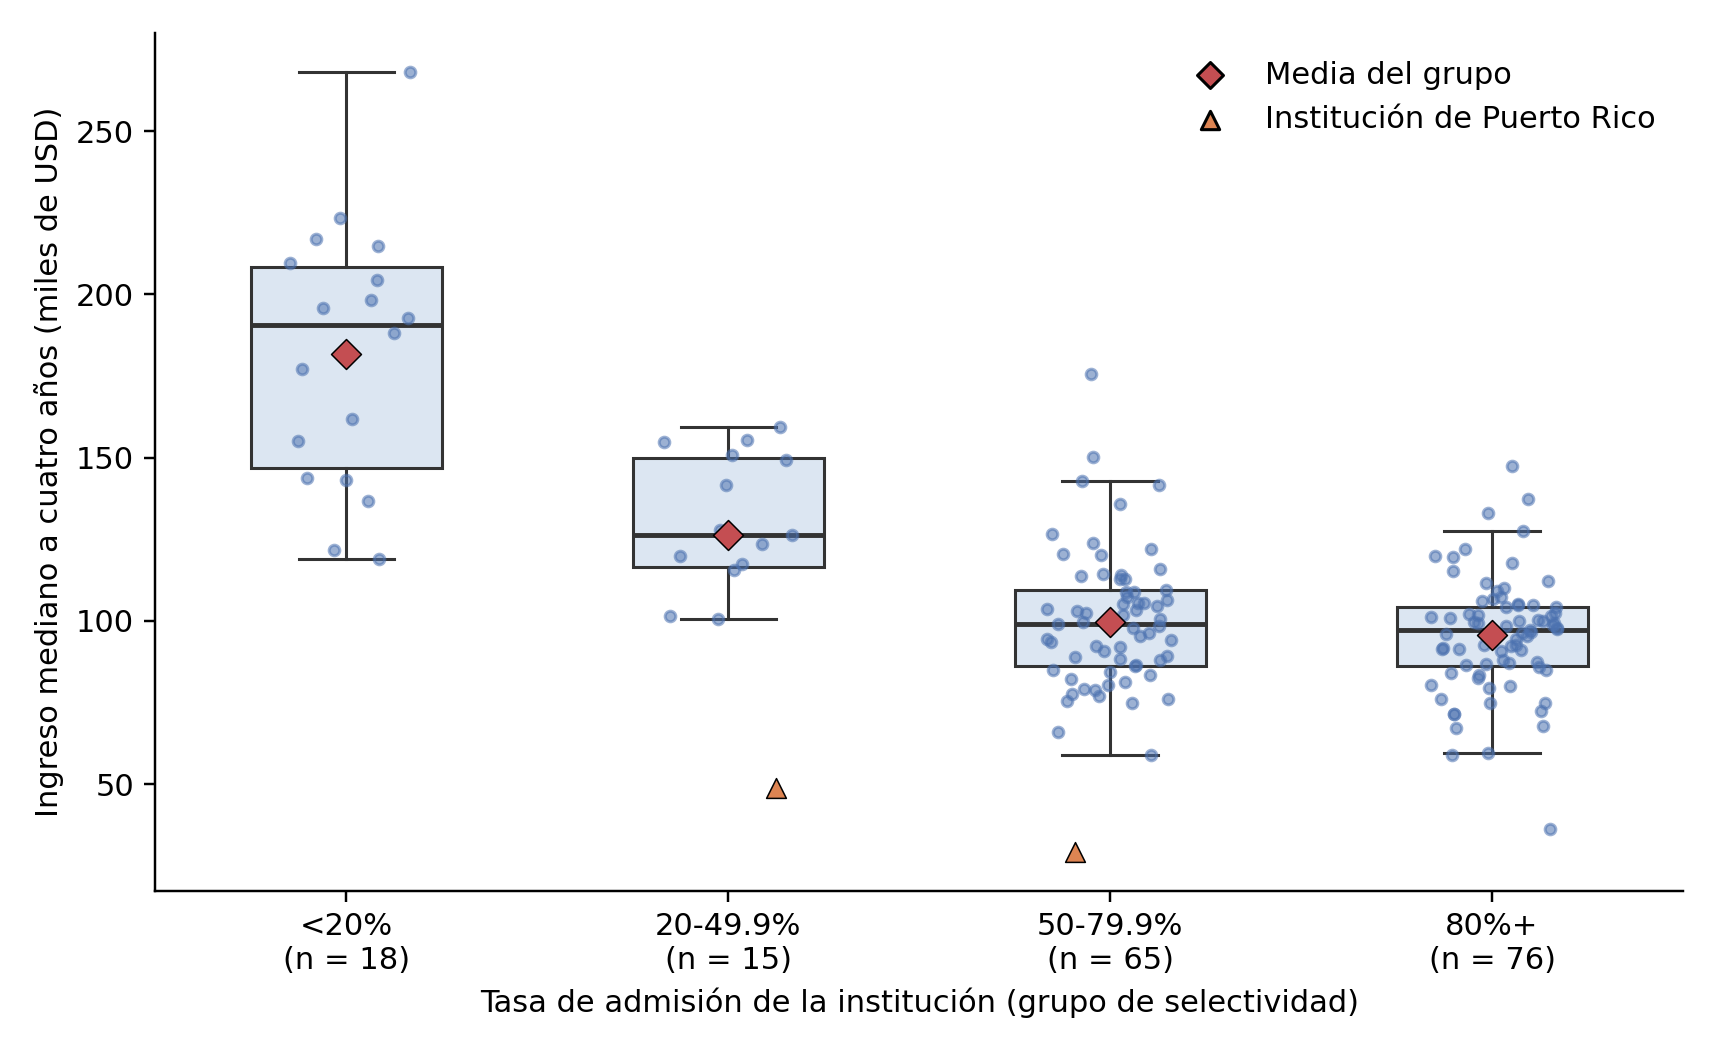

Figura 3. Ingreso por grupo de selectividad; rombos = medias, triángulos = Puerto Rico (n = 174). *Fuente:* U.S. Department of Education, College Scorecard (publicación de junio de 2026).

In [8]:
display(Image(filename=str(S / 'figura3_caja_puntos.png'), width=720))
display(Markdown('Figura 3. Ingreso por grupo de selectividad; rombos = medias, triángulos = Puerto Rico (n = 174). *Fuente:* U.S. Department of Education, College Scorecard (publicación de junio de 2026).'))

## 5. Análisis de sensibilidad

In [9]:
for line in res:
    if line.startswith('Regresion'):
        print(line)
print()
print('\n'.join(l for l in res if 'Puerto Rico' in l or l.startswith('Inter American')))

Regresion n=133; b_admit=-0.291; t=-2.74; p=0.0071; IC95=[-0.501, -0.081]; R2aj=0.696

Instituciones de Puerto Rico en la muestra:
Inter American University of Puerto Rico-Bayamon    0.338076       48801.0 Selectiva (20-49.9%)
  Inter American University of Puerto Rico-Ponce    0.527500       29212.0  Moderada (50-79.9%)
Sensibilidad sin Puerto Rico (n=172): rho=-0.474; p=5.11e-11


## 6. Qué permiten y qué no permiten concluir estos resultados
- **Sí:** existe una asociación monotónica negativa y moderada entre tasa de admisión e ingreso (ρs = −.44, IC 95 % [−.58, −.29]); la diferencia se concentra en las instituciones con admisión menor de 50 %.
- **No:** los datos no demuestran que la institución *cause* el ingreso. La selectividad refleja selección previa de estudiantes, redes, ubicación y mercados laborales regionales (como ilustran los recintos de Puerto Rico).
- **Alcance:** las conclusiones aplican a programas con resultados publicados, que tienden a ser de mayor tamaño.

*Uso de IA:* se utilizaron ChatGPT y Claude como apoyo para depurar código y revisar el informe; los resultados se verificaron ejecutando el script sobre los archivos oficiales.